In [1]:
import pandas as pd
df = pd.read_csv("../WA_Fn-UseC_-Telco-Customer-Churn.csv")

df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df = df.dropna()

In [2]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, GridSearchCV

numerical_features = ["tenure", "MonthlyCharges", "TotalCharges", "SeniorCitizen"]
categorical_features = ["gender", "Partner", "Dependents", "PhoneService", 
                        "InternetService", "Contract", "PaymentMethod"]

X = df[numerical_features + categorical_features]
y = df["Churn"].map({"Yes": 1, "No": 0})

X_train, X_test, y_train, y_test = train_test_split(
    X,y,test_size=0.2, random_state=42
)

In [3]:
preprocessor = ColumnTransformer(transformers=[
    ("num", StandardScaler(), numerical_features),
    ("cat", OneHotEncoder(), categorical_features)
                                              ])

pipeline = Pipeline(steps=[
    ("preprocessor" , preprocessor),
    ("classifier", LogisticRegression(class_weight="balanced"))
])

param_grid = {
    'classifier__C' : [0.01, 0.1, 1, 10, 100],
    'classifier__l1_ratio': [0, 1],
    'classifier__solver' : ['liblinear']                      
}

grid_search = GridSearchCV(
    pipeline,
    param_grid,
    cv=5,
    scoring='f1', 
    n_jobs=-1
)

grid_search.fit(X_train, y_train)


print("Best params:", grid_search.best_params_)
print("Best score:", grid_search.best_score_)


best_model = grid_search.best_estimator_


Best params: {'classifier__C': 10, 'classifier__l1_ratio': 0, 'classifier__solver': 'liblinear'}
Best score: 0.6303953138458966


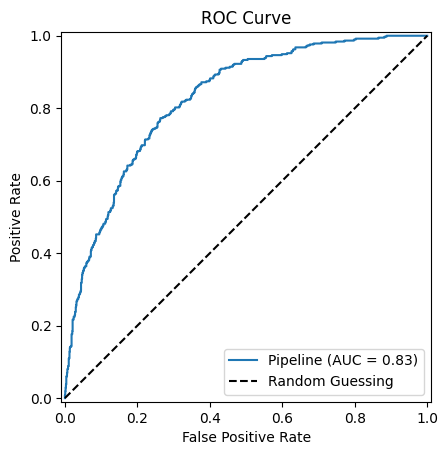

In [9]:
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, RocCurveDisplay

RocCurveDisplay.from_estimator(best_model, X_test, y_test)
plt.plot([0, 1], [0, 1], 'k--', label='Random Guessing')
plt.ylabel('Positive Rate')
plt.xlabel('False Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

In [5]:
print(classification_report(y_test, best_model.predict(X_test)))

              precision    recall  f1-score   support

           0       0.90      0.71      0.79      1033
           1       0.49      0.79      0.61       374

    accuracy                           0.73      1407
   macro avg       0.70      0.75      0.70      1407
weighted avg       0.79      0.73      0.74      1407



In [6]:
import joblib
joblib.dump(best_model, "../model/churn_model.pkl")

['../model/churn_model.pkl']

In [7]:
print(df["Churn"].value_counts())

Churn
No     5163
Yes    1869
Name: count, dtype: int64


In [8]:
from sklearn.metrics import f1_score, precision_score, recall_score

pipeline.fit(X_train, y_train)

y_pred_original = pipeline.predict(X_test)
y_pred_tuned = best_model.predict(X_test)

comparison = pd.DataFrame({
    'Original': [precision_score(y_test, y_pred_original),
                  recall_score(y_test, y_pred_original),
                  f1_score(y_test, y_pred_original)],
    'Tuned': [precision_score(y_test, y_pred_tuned),
              recall_score(y_test, y_pred_tuned),
              f1_score(y_test, y_pred_tuned)]
}, index=['Precision', 'Recall', 'F1'])

comparison['Difference'] = comparison['Tuned'] - comparison['Original']

print(comparison)

           Original     Tuned  Difference
Precision  0.494137  0.493289   -0.000849
Recall     0.788770  0.786096   -0.002674
F1         0.607621  0.606186   -0.001435
